# Analiza zbioru danych

Podsumowanie liczby plików i unikalnych nagrań na podstawie archiwów `train.7z` i `test.7z`.

In [9]:
from collections import defaultdict
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data")
TRAIN_ARCHIVE = DATA_DIR / "train.7z"
TEST_ARCHIVE = DATA_DIR / "test.7z"

IGNORED_CLASSES = {"_background_noise_"}
TARGET_LABELS = {"yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"}

In [10]:
def archive_files(archive: Path) -> list[Path]:
    result = subprocess.run(
        ["7z", "l", "-slt", str(archive)],
        check=True,
        capture_output=True,
        text=True,
    )

    files = []
    entry = {}

    def add_file() -> None:
        if entry.get("Path") and "Size" in entry and not entry.get("Attributes", "").startswith("D"):
            files.append(Path(entry["Path"]))

    for line in result.stdout.splitlines():
        if not line:
            add_file()
            entry = {}
            continue

        if " = " in line:
            key, value = line.split(" = ", 1)
            entry[key] = value

    add_file()
    return files


def speaker_id(path: Path) -> str:
    return path.name.split("_nohash_", 1)[0]

In [11]:
def train_class(path: Path) -> str | None:
    parts = path.parts
    if len(parts) != 4 or parts[:2] != ("train", "audio") or path.suffix != ".wav":
        return None

    label = parts[2]
    return None if label in IGNORED_CLASSES else label


def test_audio_file(path: Path) -> bool:
    return len(path.parts) == 3 and path.parts[:2] == ("test", "audio") and path.suffix == ".wav"


def dataset_summary(paths: list[Path]) -> pd.DataFrame:
    files_by_class = defaultdict(list)

    for path in paths:
        label = train_class(path)
        if label:
            files_by_class[label].append(path)

    rows = [
        {
            "class": label,
            "total_count": len(files),
            "unique_count": len({speaker_id(path) for path in files}),
        }
        for label, files in files_by_class.items()
    ]

    return pd.DataFrame(rows, columns=["class", "total_count", "unique_count"]).sort_values(
        "class", ignore_index=True
    )

In [12]:
train_files = archive_files(TRAIN_ARCHIVE)
test_files = [path for path in archive_files(TEST_ARCHIVE) if test_audio_file(path)]

df = dataset_summary(train_files)
df

,class,total_count,unique_count
0,bed,1713,1177
1,bird,1731,1194
2,cat,1733,1180
3,dog,1746,1209
4,down,2359,1206
5,eight,2352,1179
6,five,2357,1181
7,four,2372,1194
8,go,2372,1182
9,happy,1742,1178


In [13]:
print(f"Total number of train files: {int(df['total_count'].sum())}")
print(f"Total number of test files: {len(test_files)}")

Total number of train files: 64721
Total number of test files: 158538


In [14]:
def plot_counts(data: pd.DataFrame, title: str) -> None:
    if data.empty:
        print("No files found to plot.")
        return

    data.plot(x="class", y=["total_count", "unique_count"], kind="bar", figsize=(15, 7))
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Count Type")
    plt.tight_layout()
    plt.show()

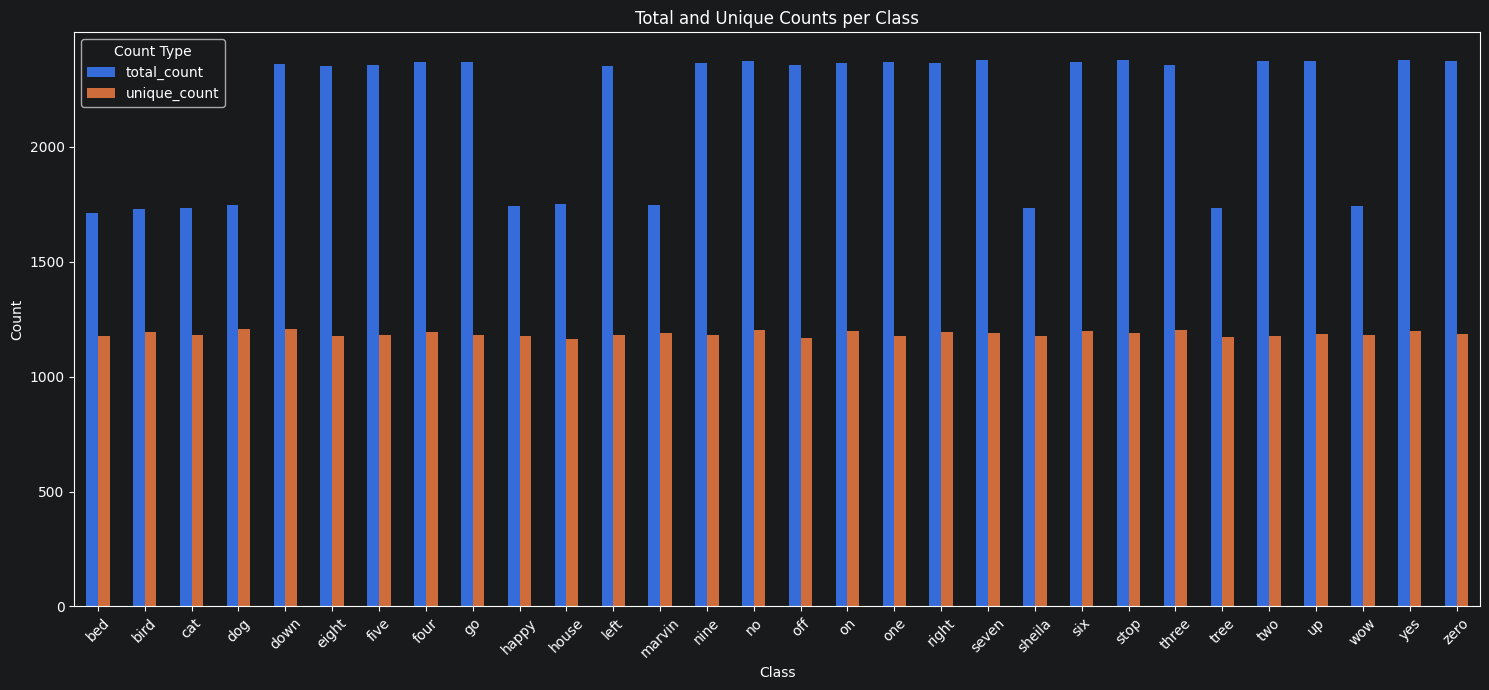

In [15]:
plot_counts(df, "Total and Unique Counts per Class")

In [16]:
target_df = df[df["class"].isin(TARGET_LABELS)].copy()
unknown_counts = df.loc[~df["class"].isin(TARGET_LABELS), ["total_count", "unique_count"]].sum()

target_df = pd.concat(
    [
        target_df,
        pd.DataFrame(
            [
                {
                    "class": "unknown",
                    "total_count": int(unknown_counts["total_count"]),
                    "unique_count": int(unknown_counts["unique_count"]),
                }
            ]
        ),
    ],
    ignore_index=True,
).sort_values("class", ignore_index=True)

target_df

,class,total_count,unique_count
0,down,2359,1206
1,go,2372,1182
2,left,2353,1180
3,no,2375,1203
4,off,2357,1170
5,on,2367,1198
6,right,2367,1194
7,stop,2380,1191
8,unknown,41039,23693
9,up,2375,1186


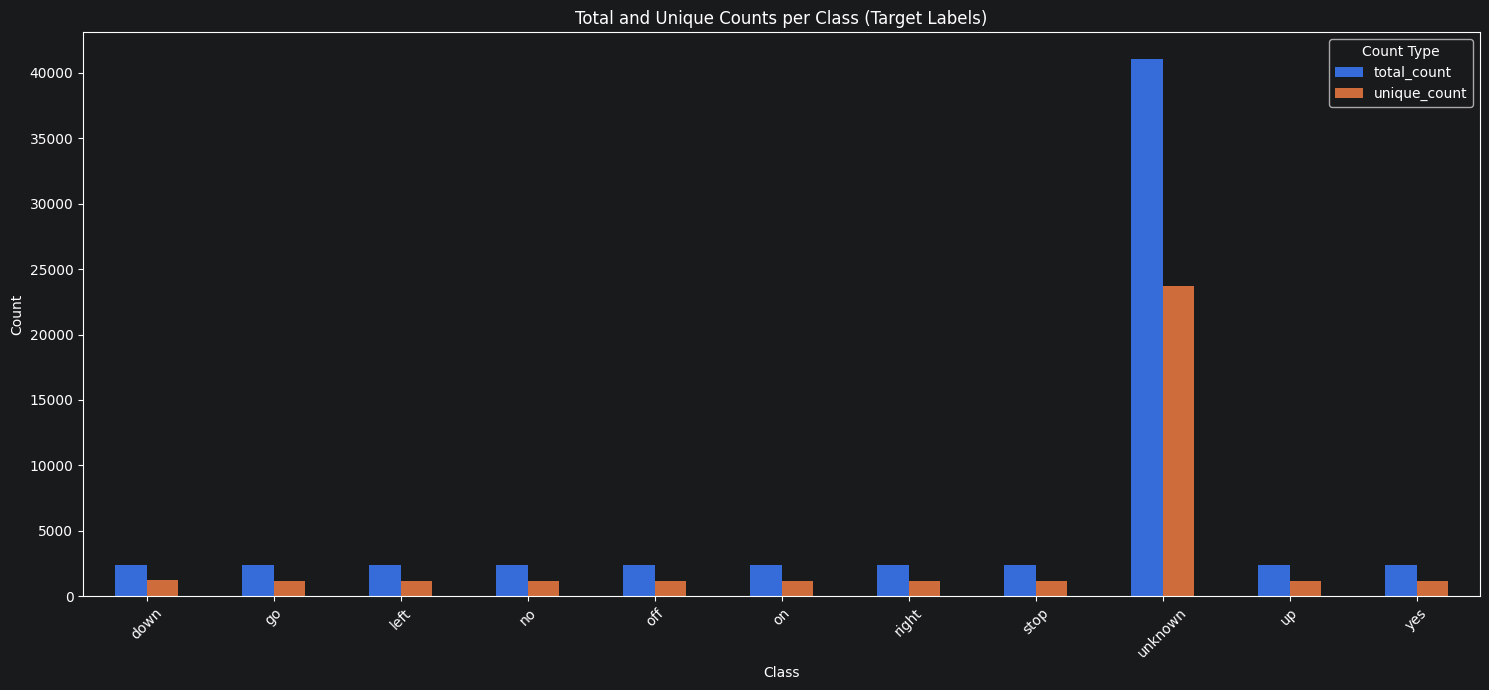

In [17]:
plot_counts(target_df, "Total and Unique Counts per Class (Target Labels)")